# **Integrales con SymPy: del flujo al stock, del stock al valor presente**

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/franperezec/propedeutico-flacso/blob/main/clases/calculo_simbolico/sympy_integrales.ipynb)

**Profesor:** Francisco Pérez M. · **Propedéutico de Matemáticas y Programación · FLACSO Ecuador**

## Objetivos de aprendizaje

Al finalizar, el estudiante podrá:

- traducir la notación de pizarra a SymPy (`integrate`, límites de integración, `oo`);
- recuperar un *stock* a partir de su *flujo* e interpretar la constante de integración como información económica;
- calcular valores presentes con horizonte infinito y reconocer la condición de convergencia $r>g$ como una condición **económica**;
- usar SymPy para resolver integrales cuyas técnicas manuales aún no conocen (adelanto: integración por partes).

**Cronograma**

| Bloque | Min | Pregunta económica |
|---|---|---|
| 0. El puente pizarra → SymPy | 3′ | — |
| 1. Del flujo al stock | 8′ | ¿Cuánto capital tiene la empresa? |
| 2. Horizonte infinito | 10′ | ¿Cuánto vale hoy un flujo perpetuo? |
| 3. SymPy sabe lo que ustedes aún no | 6′ | ¿Cuánto bienestar da consumirlo? |
| 4. Cierre | 3′ | — |

## Preparación del entorno

### Google Colab

Las bibliotecas suelen estar instaladas. Si aparece un error, ejecute una sola vez:

```python
%pip install sympy numpy matplotlib
```

### VS Code

**Windows — PowerShell**

```powershell
py -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install sympy numpy matplotlib ipykernel
```

**macOS o Linux**

```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install sympy numpy matplotlib ipykernel
```

En VS Code, abra el notebook y seleccione como kernel el intérprete de `.venv`.

In [1]:
# Ejecute esta celda solo si necesita instalar las bibliotecas.
# Quite el símbolo # de la línea siguiente y ejecútela una sola vez.
# %pip install sympy numpy matplotlib


In [2]:
%matplotlib inline

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# Presentación matemática de las expresiones simbólicas.
sp.init_printing(use_latex='mathjax')


## Bloque 0 · El puente pizarra → SymPy

SymPy es un sistema de **álgebra simbólica**: manipula símbolos exactos, no aproximaciones numéricas.

| A mano | En SymPy |
|---|---|
| declarar la variable $x$ | `x = sp.symbols('x')` |
| $\displaystyle\int f(x)\,dx$ | `sp.integrate(f, x)` |
| $\displaystyle\int_a^b f(x)\,dx$ | `sp.integrate(f, (x, a, b))` |
| $\infty$ | `sp.oo` |
| $\dfrac{d}{dx}F(x)$ (para verificar) | `sp.diff(F, x)` |

In [3]:
# Variable simbólica de trabajo.
x = sp.symbols("x")

In [4]:
# definimos la función a integrar
f = 3*x**2 + 2*x

antiderivada = sp.integrate(f, x)                # integral indefinida
display(sp.Eq(sp.Integral(f, x), antiderivada))



⌠                          
⎮ ⎛   2      ⎞       3    2
⎮ ⎝3⋅x  + 2⋅x⎠ dx = x  + x 
⌡                          

In [5]:
#comprobar integral derivando
derivada = sp.diff(antiderivada, x)
display(sp.Eq(sp.Derivative(antiderivada, x), derivada))




d ⎛ 3    2⎞      2      
──⎝x  + x ⎠ = 3⋅x  + 2⋅x
dx                      

In [6]:
#integral definida
area = sp.integrate(f, (x, 0, 2))                # integral definida
display(sp.Eq(sp.Integral(f, (x, 0, 2)), area))

2                     
⌠                     
⎮ ⎛   2      ⎞        
⎮ ⎝3⋅x  + 2⋅x⎠ dx = 12
⌡                     
0                     

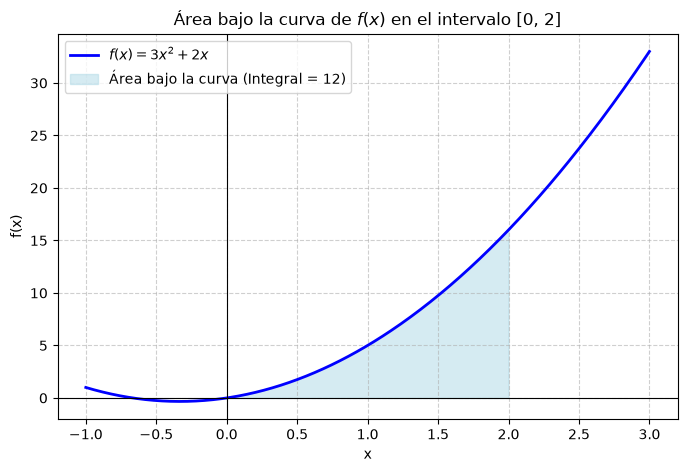

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Convertir la expresión de SymPy a una función numérica
f_num = sp.lambdify(x, f, 'numpy')

# Definir el rango de valores para x
x_vals = np.linspace(-1, 3, 400)
y_vals = f_num(x_vals)

# Crear la figura
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label=r'$f(x) = 3x^2 + 2x$')

# Sombrear el área bajo la curva entre 0 y 2
x_fill = np.linspace(0, 2, 100)
y_fill = f_num(x_fill)
plt.fill_between(x_fill, 0, y_fill, color='lightblue', alpha=0.5, label='Área bajo la curva (Integral = 12)')

# Añadir líneas de referencia
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Etiquetas y título
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Área bajo la curva de $f(x)$ en el intervalo [0, 2]')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar el gráfico
plt.show()


Dos observaciones antes de seguir:

1. **SymPy no escribe la $+C$.** No es un descuido: devuelve *una* antiderivada. La constante es responsabilidad nuestra — y en economía, como veremos ahora mismo, la constante es *información*.
2. La definida se escribe igual que la indefinida, empaquetando variable y límites en una tupla `(x, a, b)`.

## Bloque 1 · Del flujo al stock

Una empresa invierte con un **flujo** que crece exponencialmente:

$$I(t) = I_0\,e^{g t} \qquad \text{(millones de USD por año)}$$

**Pregunta 1:** ¿cuál es la función de capital $K(t)$?

La inversión es la *tasa de cambio* del capital: $K'(t) = I(t)$. Recuperar el stock desde el flujo es, exactamente, integrar:

$$K(t) = \int I(t)\,dt$$

In [8]:
# Símbolos económicos. Los supuestos (positive=True) importan:
# le dicen a SymPy qué sabe de cada símbolo y le permiten simplificar con seguridad.
t = sp.symbols("t", nonnegative=True)            # tiempo
I0, K0 = sp.symbols("I_0 K_0", positive=True)    # inversión inicial, capital inicial
g = sp.symbols("g", positive=True)               # tasa de crecimiento de la inversión

I = I0*sp.exp(g*t)                               # flujo de inversión

K_una = sp.integrate(I, t)                       # UNA antiderivada (SymPy omite la constante)
display(sp.Eq(sp.Integral(I, t), K_una))

⌠                  g⋅t
⎮     g⋅t      I₀⋅ℯ   
⎮ I₀⋅ℯ    dt = ───────
⌡                 g   

La familia completa de antiderivadas es $K(t) = \dfrac{I_0}{g}e^{gt} + C$. ¿Quién fija $C$? **La condición inicial**: el capital con el que la empresa arranca, $K(0)=K_0$.

**Cuidado con la regla memorizada.** En el ejemplo clásico *costo marginal → costo total*, la constante resulta ser el costo fijo. Aquí **no**: en $t=0$ el término $\frac{I_0}{g}e^{0}=\frac{I_0}{g}$ ya vale algo distinto de cero, así que $C$ tiene que compensarlo. La constante se *determina* con la condición inicial; no se *adivina*.

In [9]:
C = sp.symbols("C")
K_general = K_una + C

condicion_inicial = sp.Eq(K_general.subs(t, 0), K0)     # K(0) = K_0
display(condicion_inicial)

C_solucion = sp.solve(condicion_inicial, C)[0]
display(sp.Eq(C, C_solucion))                           # C = K_0 - I_0/g  (¡no es K_0!)

K = K_general.subs(C, C_solucion)
display(sp.Eq(sp.Function("K")(t), sp.simplify(K)))

    I₀     
C + ── = K₀
    g      

      I₀     
C = - ── + K₀
      g      

           g⋅t            
       I₀⋅ℯ    - I₀ + K₀⋅g
K(t) = ───────────────────
                g         

In [10]:
# Verificar SIEMPRE derivando.
# Si K es correcta, K'(t) - I(t) debe ser exactamente 0.
display(I)
display(sp.simplify(sp.diff(K, t)))
display(sp.simplify(sp.diff(K, t) - I))

    g⋅t
I₀⋅ℯ   

    g⋅t
I₀⋅ℯ   

0

**Pregunta 2:** ¿cuánto capital se **acumuló** entre $t=0$ y un horizonte $T$?

Eso es la integral definida:

$$\Delta K = \int_0^{T} I(t)\,dt = K(T) - K(0)$$

In [11]:
T = sp.symbols("T", positive=True)               # horizonte

Delta_K = sp.integrate(I, (t, 0, T))
display(sp.Eq(sp.Integral(I, (t, 0, T)), sp.simplify(Delta_K)))



T                           
⌠                 ⎛ T⋅g    ⎞
⎮     g⋅t      I₀⋅⎝ℯ    - 1⎠
⎮ I₀⋅ℯ    dt = ─────────────
⌡                    g      
0                           

In [12]:
# Teorema Fundamental del Cálculo, verificación:
display(sp.simplify(Delta_K))
display(sp.simplify((K.subs(t, T))))
display(sp.simplify((K.subs(t, 0))))
display(sp.simplify((K.subs(t, T) - K.subs(t, 0))))
display(sp.simplify(Delta_K - (K.subs(t, T) - K.subs(t, 0))))

   ⎛ T⋅g    ⎞
I₀⋅⎝ℯ    - 1⎠
─────────────
      g      

    T⋅g            
I₀⋅ℯ    - I₀ + K₀⋅g
───────────────────
         g         

K₀

   ⎛ T⋅g    ⎞
I₀⋅⎝ℯ    - 1⎠
─────────────
      g      

0

> **Stock final = stock inicial + flujo acumulado.** La constante de integración: es la condición inicial del sistema económico — y no siempre coincide con el stock inicial.

## Bloque 2 · Horizonte infinito: el valor presente

La empresa ya operó su capital y ahora genera un flujo de beneficios **constante y perpetuo**: $F(t)=F_0$ millones al año, para siempre. Con tasa de descuento $r$, ¿cuánto vale **hoy** ese flujo?

$$VP = \int_0^{\infty} F_0\,e^{-rt}\,dt$$

La teoría de hoy cubrió $[a,b]$ finito. ¿Qué significa integrar hasta $\infty$? **Es una definición**, no un truco:

$$\int_0^{\infty} \;\equiv\; \lim_{T\to\infty} \int_0^{T}$$

Y lo mejor: esa definición se puede **ejecutar**, paso a paso.

In [13]:
F0 = sp.symbols("F_0", positive=True)            # flujo anual
r = sp.symbols("r", positive=True)               # tasa de descuento

# Paso 1: integral definida hasta un horizonte T (esto ya lo dominan)
VP_T = sp.integrate(F0*sp.exp(-r*t), (t, 0, T))
display(sp.Eq(sp.Function("VP")(T), sp.simplify(VP_T)))

                 -T⋅r
        F₀   F₀⋅ℯ    
VP(T) = ── - ────────
        r       r    

In [14]:
# Paso 2: la definición, ejecutada — límite cuando T crece sin cota
VP_limite = sp.limit(VP_T, T, sp.oo)
display(sp.Eq(sp.Symbol("VP"), VP_limite))



     F₀
VP = ──
     r 

In [15]:
# Paso 3: SymPy permite hacerlo en un solo paso, integrando directamente hasta oo
VP_directo = sp.integrate(F0*sp.exp(-r*t), (t, 0, sp.oo))
display(sp.Eq(sp.Symbol("VP"), VP_directo))

     F₀
VP = ──
     r 

In [16]:
# Control de sanidad: F0 = 100 millones/año, r = 5% anual
display(VP_directo.subs({F0: 100, r: sp.Rational(5, 100)}))

2000

$VP = \dfrac{F_0}{r}$: la fórmula de la **perpetuidad** que conocen de finanzas. Ahora saben de qué integral viene — y que el $e^{-rt}$ del descuento continuo es lo que hace finita una suma infinita de pagos.

### El flujo que crece — predigan antes de ejecutar

Ahora los beneficios **crecen**: $F(t)=F_0e^{gt}$ (piensen en dividendos que crecen a tasa $g$).

$$VP = \int_0^{\infty} F_0\,e^{gt}\,e^{-rt}\,dt = \int_0^{\infty} F_0\,e^{(g-r)t}\,dt$$

¿este valor presente es finito *siempre*? ¿De qué depende? Miren el signo del exponente.*

In [17]:
# Integral definida hasta T del flujo creciente — sin decirle a SymPy quién gana entre g y r
VP_T_creciente = sp.integrate(F0*sp.exp((g - r)*t), (t, 0, T))
VP_T_creciente

⎧      T⋅(g - r)                        
⎪  F₀⋅ℯ              F₀                 
⎪- ───────────── + ──────  for g - r ≠ 0
⎨     -g + r       -g + r               
⎪                                       
⎪          F₀⋅T              otherwise  
⎩                                       

SymPy nos devuelve **dos posibles escenarios**:

- **Si $g = r$**: obtenemos $VP(T) = F_0\,T$. Esto significa que el valor presente crece sin límite a medida que se aleja el horizonte temporal. Económicamente, el flujo crece exactamente al mismo ritmo al que la tasa de descuento lo reduce, por lo que cada año aporta exactamente la misma cantidad al valor de hoy.
- **Si $g \neq r$**: el comportamiento a largo plazo depende del término $e^{(g-r)T}$ cuando $T\to\infty$. Para que la integral converja (es decir, para que el valor presente total sea finito), necesitamos que la exponencial tienda a cero. Esto ocurre $\iff g - r < 0 \iff \boxed{r > g}$.

Noten que esta desigualdad **no la impusimos nosotros: es una exigencia estrictamente matemática para que haya convergencia**.

**El apunte macroeconómico: la divergencia de Piketty**
¿Les resulta familiar la condición $r > g$? Es la famosa desigualdad que el economista Thomas Piketty situó en el centro de su obra *El capital en el siglo XXI*. Piketty sostiene que cuando la tasa de rendimiento del capital ($r$) es sistemáticamente mayor que la tasa de crecimiento de la economía ($g$), la riqueza acumulada en el pasado crece más rápido que la producción y los salarios. Como estamos viendo matemáticamente, el valor de los flujos de capital es altísimo bajo esta condición; socialmente, Piketty argumenta que esto conduce a una concentración patrimonial extrema y a un aumento estructural de la desigualdad.

Verifiquémoslo con números antes de formalizar la solución:

In [18]:
# Caso sano: r > g   (r = 5%, g = 2%)
valores_ok = {F0: 100, r: sp.Rational(5, 100), g: sp.Rational(2, 100)}
print("r > g: el VP converge")
for horizonte in [50, 200, 1000]:
    vp = float(VP_T_creciente.subs(valores_ok).subs(T, horizonte))
    print(f"   VP(T={horizonte:>4}) = {vp:>12,.2f}")

# Caso patológico: r < g   (r = 2%, g = 5%)
valores_mal = {F0: 100, r: sp.Rational(2, 100), g: sp.Rational(5, 100)}
print("\nr < g: el VP explota")
for horizonte in [50, 200, 1000]:
    vp = float(VP_T_creciente.subs(valores_mal).subs(T, horizonte))
    print(f"   VP(T={horizonte:>4}) = {vp:>16,.2f}")

r > g: el VP converge
   VP(T=  50) =     2,589.57
   VP(T= 200) =     3,325.07
   VP(T=1000) =     3,333.33

r < g: el VP explota
   VP(T=  50) =        11,605.63
   VP(T= 200) =     1,341,429.31
   VP(T=1000) = 35,621,581,938,411,540.00


La tabla confirma la predicción. Ahora **díganle a SymPy lo que descubrieron**: si $r>g$, la brecha $s \equiv r-g$ es un número positivo. Declarándola como símbolo positivo, la impropia sale limpia:

In [19]:
s = sp.symbols("s", positive=True)               # s = r - g > 0: descuento neto de crecimiento

VP_creciente = sp.integrate(F0*sp.exp(-s*t), (t, 0, sp.oo))
display(sp.Eq(sp.Symbol("VP"), VP_creciente))

# Reescrito en términos de r y g:
display(sp.Eq(sp.Symbol("VP"), VP_creciente.subs(s, r - g)))

# Control contra la tabla numérica: F0=100, r=5%, g=2%  ->  100/0.03
resultado_exacto = VP_creciente.subs(s, r - g).subs(valores_ok)
display(resultado_exacto)
print("=", float(resultado_exacto), " <- coincide con la convergencia de la tabla")

     F₀
VP = ──
     s 

       F₀  
VP = ──────
     -g + r

10000/3

= 3333.3333333333335  <- coincide con la convergencia de la tabla


> Integrar hasta $\infty$ es tomar un límite — y la condición de convergencia de la integral es una condición **económica**: $r>g$. El resultado $VP=\dfrac{F_0}{r-g}$.

**El valor presente es un área**

El integrando $F_0e^{(g-r)t}$ es el flujo *ya descontado a valor de hoy*. El $VP$ es, literalmente, el área bajo esa curva.

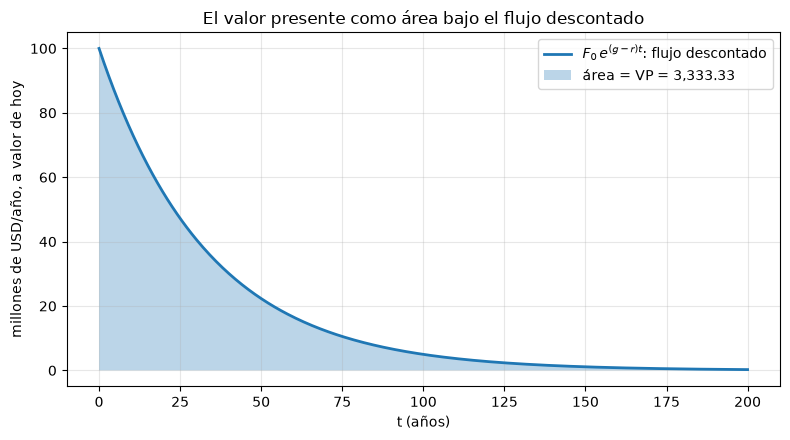

Área hasta T=200: 3,325.13 (el 99.7% del VP: la cola lejana casi no aporta — eso ES la convergencia)


In [20]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

F0_n, r_n, g_n = 100, 0.05, 0.02                  # los valores del caso sano
tt = np.linspace(0, 200, 400)
flujo_descontado = F0_n*np.exp((g_n - r_n)*tt)

plt.figure(figsize=(8, 4.5))
plt.plot(tt, flujo_descontado, lw=2, label=r"$F_0\,e^{(g-r)t}$: flujo descontado")
plt.fill_between(tt, 0, flujo_descontado, alpha=0.3,
                 label=f"área = VP = {F0_n/(r_n - g_n):,.2f}")
plt.xlabel("t (años)")
plt.ylabel("millones de USD/año, a valor de hoy")
plt.title("El valor presente como área bajo el flujo descontado")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Área hasta T=200: {np.trapezoid(flujo_descontado, tt):,.2f} "
      f"(el 99.7% del VP: la cola lejana casi no aporta — eso ES la convergencia)")

## Bloque 3 · SymPy sabe lo que ustedes todavía no

Última pregunta: el dueño de la empresa **consume** esos dividendos crecientes, $c(t)=c_0e^{gt}$. En macroeconomía, el bienestar de toda una vida se mide como **utilidad descontada** — el funcional objetivo del modelo de Ramsey, que verán formalmente en macro:

$$U = \int_0^{\infty} e^{-\rho t}\,\ln\!\big(c_0 e^{gt}\big)\,dt$$

donde $\rho$ es la **tasa de impaciencia**. Antes de integrar, separemos el logaritmo con una propiedad que conocen de siempre:

$$\ln\!\big(c_0e^{gt}\big) = \ln c_0 + g\,t
\quad\Longrightarrow\quad
U = \ln c_0 \underbrace{\int_0^{\infty} e^{-\rho t}\,dt}_{\text{¡ya la calculamos!}} \;+\; g\underbrace{\int_0^{\infty} t\,e^{-\rho t}\,dt}_{\text{nueva}}$$

In [21]:
rho, c0 = sp.symbols("rho c_0", positive=True)   # impaciencia, consumo inicial

# Pieza 1: es la perpetuidad del Bloque 2 con F_0 = 1
pieza_conocida = sp.integrate(sp.exp(-rho*t), (t, 0, sp.oo))
display(pieza_conocida)

# Pieza 2: a mano exige una técnica que AÚN no han visto (integración por partes).
# SymPy ya la conoce.
pieza_nueva = sp.integrate(t*sp.exp(-rho*t), (t, 0, sp.oo))
display(pieza_nueva)

1
─
ρ

1 
──
 2
ρ 

In [22]:
U = sp.log(c0)*pieza_conocida + g*pieza_nueva
display(sp.Eq(sp.Symbol("U"), U))



    g    log(c₀)
U = ── + ───────
     2      ρ   
    ρ           

In [23]:
# Verificación: la integral original completa, directa, sin separar el logaritmo
U_directa = sp.integrate(sp.exp(-rho*t)*sp.log(c0*sp.exp(g*t)), (t, 0, sp.oo))

display(U )
display(U_directa)
display(sp.simplify(U - U_directa))

g    log(c₀)
── + ───────
 2      ρ   
ρ           

g    log(c₀)
── + ───────
 2      ρ   
ρ           

0

$$U = \frac{\ln c_0}{\rho} + \frac{g}{\rho^{2}}$$

Interpretación económica: el **nivel** de consumo vale $\ln c_0/\rho$; el **crecimiento** vale $g/\rho^{2}$. La impaciencia entra *al cuadrado* en el término de crecimiento — crecer beneficia sobre todo al futuro, y el futuro es exactamente lo que la impaciencia castiga. Veámoslo con números:

In [24]:
parametros_comunes = {c0: 100, g: sp.Rational(2, 100)}

for nombre, rho_valor in [("impaciente (rho = 6%)", sp.Rational(6, 100)),
                          ("paciente   (rho = 3%)", sp.Rational(3, 100))]:
    valores = {**parametros_comunes, rho: rho_valor}
    nivel = float((sp.log(c0)/rho).subs(valores))
    crecimiento = float((g/rho**2).subs(valores))
    print(f"{nombre}:  U = {nivel + crecimiento:7.2f}"
          f"   (nivel {nivel:7.2f}  +  crecimiento {crecimiento:6.2f})")

impaciente (rho = 6%):  U =   82.31   (nivel   76.75  +  crecimiento   5.56)
paciente   (rho = 3%):  U =  175.73   (nivel  153.51  +  crecimiento  22.22)


Al **duplicar la paciencia** (de $\rho=6\%$ a $\rho=3\%$), el valor del nivel se duplica… pero el valor del crecimiento se **cuadruplica**. Eso es $\rho^2$ operando.

> En una economía que crece, la paciencia vale al cuadrado. Y SymPy les permite usar *hoy* técnicas que la teoría formalizará *después*.

## Bloque 4

**Las cuatro conclusiones de los bloques vistos:**

0. SymPy nos ayuda a resolver integrales simbólicamente.
1. Stock final = stock inicial + flujo acumulado; la constante de integración es la condición inicial (y no siempre es el stock inicial).
2. Integrar hasta $\infty$ es tomar un límite de la integral de 0 a T, y la condición de convergencia es una condición económica: $r>g$.
3. En una economía que crece, la paciencia vale al cuadrado ($g/\rho^2$) — y SymPy hace el álgebra para que ustedes hagan la economía.

**Caja de herramientas de la sesión:**

| Comando | Qué hace | Dónde lo usamos |
|---|---|---|
| `sp.symbols("g", positive=True)` | declara símbolos *con supuestos* | todos los bloques |
| `sp.integrate(f, t)` | antiderivada (recuerden: sin $+C$) | $K(t)$ |
| `sp.integrate(f, (t, 0, T))` | integral definida | $\Delta K$, $VP(T)$ |
| `sp.limit(expr, T, sp.oo)` | límite | definición de la impropia |
| `sp.integrate(f, (t, 0, sp.oo))` | impropia en un paso | $VP$, $U$ |
| `sp.diff`, `sp.simplify` | verificar integrales derivando | cada bloque |
| `.subs({...})`, `float()` | evaluación numérica